# Only $t_0$

## Import Packages

In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.initializers import he_normal                                           
from tensorflow.keras.optimizers import Adam                                                  
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import LSTM, Dense, Dropout, Reshape, Conv2D                     
import cartopy.crs as ccrs                                                                    
import cartopy.feature as cfeature                                                            
import warnings
warnings.filterwarnings("ignore")
import datetime

In [5]:
!nvidia-smi

Sun May 18 11:04:06 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.163.01             Driver Version: 550.163.01     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:01:00.0 Off |                   On |
| N/A   33C    P0             89W /  400W |                  N/A   |     N/A      Default |
|                                         |                        |              Enabled |
+-----------------------------------------+-----

In [6]:
print(tf.config.list_physical_devices('GPU'))

[]


In [ ]:
from joblib import dump

## Import Datasets

In [ ]:
test_data_X = pd.read_csv("/content/drive/MyDrive/Zambia/test-ob-to-map-input-t0.csv")
test_data_y_lt1 = np.load("/content/drive/MyDrive/Zambia/test-ob-to-map-target-t1.npy")
test_data_y_lt0 = np.load("/content/drive/MyDrive/Zambia/test-ob-to-map-target-t0.npy")

In [ ]:
train_data_X = pd.read_csv("/content/drive/MyDrive/Zambia/train-ob-to-map-input-t0.csv")
train_data_y_lt1 = np.load("/content/drive/MyDrive/Zambia/train-ob-to-map-target-t1.npy")

In [ ]:
fract_storm_test = np.sum(test_data_y_lt1) / len(test_data_y_lt1.flatten())
fract_storm_train = np.sum(train_data_y_lt1) / len(train_data_y_lt1.flatten())

print(fract_storm_test)
print(fract_storm_train)

0.049859731416934616
0.05191429246474491


### Preprocessing

Scaling helps convergence faster

In [ ]:
# Define time periods and corresponding suffixes
time_periods = ["", "_30", "_60", "_90", "_120"]

# Define storm attributes to be scaled
attributes_to_scale = ["wp", "size", "ds"]

# Generate headers for attributes to scale across all time periods
to_scale = ",".join([
    f"{attr}{suffix}"
    for attr in attributes_to_scale
    for suffix in time_periods
    for i in range(1)
]).rstrip(',')

# Define base time headers
time_headers = ["year", "month", "day", "hour", "minute"]

# Generate headers for time variables across all time periods
t = ",".join([
    f"{col}{suffix}"
    for suffix in time_periods
    for col in time_headers
]).rstrip(',')

In [ ]:
def log_transform(df, keys):
    df_copy = df.copy()
    for key in keys:
        # Log transformation with handling for non-positive values
        df_copy[key] = np.where(df_copy[key] > 0, np.log(df_copy[key]), np.log(df_copy[key] + 1e-8))
    return df_copy

def sqrt_transform(df, keys):
    df_copy = df.copy()
    for key in keys:
        # Square root transformation with handling for negative values
        df_copy[key] = np.where(df_copy[key] >= 0, np.sqrt(df_copy[key]), df_copy[key])
    return df_copy

In [ ]:
def prepare(df):
    df = log_transform(df, to_scale.split(','))
    df = sqrt_transform(df, t.split(','))
    return df

In [ ]:
transform = True
if transform:
    train_X = prepare(train_data_X)
    test_X = prepare(test_data_X)

In [ ]:
train_X_t0, validation_X_t0, train_y_lt1, validation_y_lt1 = train_test_split(train_X, train_data_y_lt1, test_size=0.3, random_state=12)

### Scaling

In [ ]:
scaler = StandardScaler()
std_X_train = scaler.fit_transform(train_X_t0)
std_X_val = scaler.transform(validation_X_t0)
std_X_test = scaler.transform(test_X)

In [ ]:
dump(scaler, "/content/drive/MyDrive/Zambia/Zambia-scaler-lt1.bin", compress=True)

['/content/drive/MyDrive/Zambia/Zambia-scaler-lt1.bin']

In [ ]:
x_train = std_X_train.reshape(len(std_X_train), 5, 10)
y_train = train_y_lt1

x_val = std_X_val.reshape(len(validation_X_t0), 5, 10)
y_val = validation_y_lt1

x_test = std_X_test.reshape(len(test_X), 5, 10)
y_test = test_data_y_lt1

In [ ]:
def apply_maximum_filter_to_batch(y_batch, filter_size):
    """
    Applies a maximum filter to each element in the batch.

    Parameters:
    - y_batch: Tensor of shape (batch_size, height, width).
    - filter_size: Tuple defining the size of the maximum filter.

    Returns:
    - A tensor of the same shape as y_batch with the maximum filter applied.
    """
    # Apply maximum filter to each element in the batch
    filtered_batch = tf.map_fn(
        lambda y: tf.numpy_function(ndimage.maximum_filter, [y, filter_size], tf.int64),
        y_batch,
        fn_output_signature=tf.int64
    )
    return filtered_batch

In [ ]:
# Parameters for the output shape
resolution_y = 23  # Height of the output
resolution_x = 26  # Width of the output

# Model Definition
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(5, 10)),  # Input shape as specified (5 timesteps, 10 features)

    # LSTM layer with small units
    LSTM(16, activation="relu", return_sequences=False),  # 16 units for the LSTM

    # Dropout for regularization
    Dropout(0.2),

    # Dense layer to output the desired number of features
    Dense(resolution_y * resolution_x, activation='relu'),  # Output the desired number of units for (23, 26) output shape

    # Reshaping to the target resolution (23, 26)
    Reshape((resolution_y, resolution_x, 1)),  # Reshape to (23, 26, 1)

    # Convolutional layer with fewer filters
    Conv2D(16, (3, 3), activation='relu', padding='same', kernel_initializer=he_normal()),  # 16 filters

    # Output layer with 1 channel (since we need only 1 value per pixel)
    Conv2D(1, (1, 1), activation='sigmoid', padding='same', kernel_initializer=he_normal())  # Single channel output
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 16)                  │           1,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 598)                 │          10,166 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_1 (Reshape)                  │ (None, 23, 26, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 23, 26, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 23, 26, 1)           │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,071 (47.15 KB)

 Trainable params: 12,071 (47.15 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cl_thresholds = 0.15

METRICS = [
      tf.keras.metrics.MeanSquaredError(name='bs'),
      tf.keras.metrics.TruePositives(name='tp'),
      tf.keras.metrics.TrueNegatives(name='tn'),
      tf.keras.metrics.Recall(name='recall', thresholds = cl_thresholds),
      tf.keras.metrics.Precision(name='precision', thresholds = cl_thresholds),
      tf.keras.metrics.AUC(name='auc'),
      tf.keras.metrics.AUC(name='prc', curve='PR'),
      tf.keras.metrics.F1Score(name = 'f1_score',  threshold = cl_thresholds),
]

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",
    verbose=1,
    patience=10,
    mode='max',
    restore_best_weights=True)

In [ ]:
optimizer = Adam(clipvalue=1.0, learning_rate=1e-3)
model.compile(optimizer=optimizer,
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
              metrics=[tf.keras.metrics.AUC(name='auc')])

In [ ]:
model_history = model.fit(x_train,
                          y_train,
                          epochs=500,
                          batch_size = 1024,
                          callbacks = [early_stopping],
                          validation_data=(x_val, y_val)
                        )

Epoch 1/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - auc: 0.7998 - loss: 0.1727 - val_auc: 0.8084 - val_loss: 0.1714
Epoch 2/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.7994 - loss: 0.1732 - val_auc: 0.8086 - val_loss: 0.1713
Epoch 3/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.7995 - loss: 0.1732 - val_auc: 0.8086 - val_loss: 0.1713
Epoch 4/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.8006 - loss: 0.1725 - val_auc: 0.8087 - val_loss: 0.1713
Epoch 5/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - auc: 0.8003 - loss: 0.1727 - val_auc: 0.8090 - val_loss: 0.1712
Epoch 6/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - auc: 0.7999 - loss: 0.1732 - val_auc: 0.8090 - val_loss: 0.1712
Epoch 7/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - auc: 0.8011 - loss: 0.1723 - val_auc: 0.8089 - val_loss: 0.1712
Epoch 8/500
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.8001 - loss: 0.1731 - val_auc: 0.8091 - val_loss: 0.1711
Epoch 9/500
100/100 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
pred_y_train = model.predict(x_train).flatten()
pred_y_test = model.predict(x_test).flatten()

3173/3173 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [ ]:
def plot_roc(name, labels, predictions, **kwargs):
  fp, tp, _ = metrics.roc_curve(labels, predictions)
  plt.plot(100*fp, 100*tp, label=name, linewidth=2, **kwargs)
  plt.xlabel('False alarm [%]')
  plt.ylabel('Hit [%]')
  plt.xlim([0,100])
  plt.ylim([0,100])
  plt.grid(True)
  ax = plt.gca()
  ax.set_aspect('equal')

In [ ]:
auc_train = roc_auc_score(y_train.flatten(), pred_y_train)
auc_test = roc_auc_score(y_test.flatten(), pred_y_test)

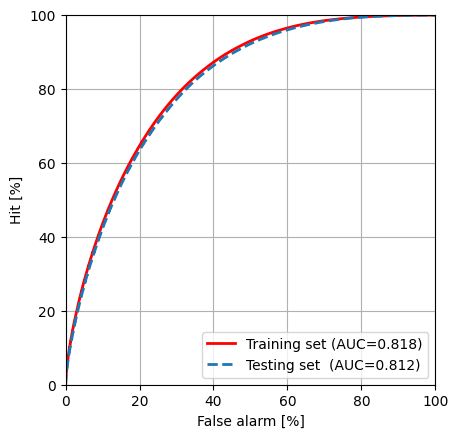

In [ ]:
plot_roc(f"Training set (AUC={auc_train:.3f})", y_train.flatten(), pred_y_train.flatten(), color="red")
plot_roc(f"Testing set  (AUC={auc_test:.3f})", y_test.flatten(), pred_y_test.flatten(), linestyle='--')
plt.legend(loc='lower right');

### Reliability diagram

In [ ]:
def reliability_curve(y, y_pred, bin_size=0.1, count_pred_per_bin=100):
  y = np.array(y)
  y_pred = np.array(y_pred)
  bins = np.arange(0, 1+bin_size, bin_size)
  bin_centers = [(b1 + b2) / 2 for b1, b2 in zip(bins[:-1], bins[1:])]
  prop_positive = []
  bin_center_ax = []
  no_pred_per_bin = []
  for b1, b2, bc in zip(bins[:-1], bins[1:], bin_centers):
    in_bin = np.logical_and(y_pred >= b1, y_pred < b2)
    no_predictions_per_bin = np.sum(in_bin)
    no_positive_per_bin = np.sum(y[in_bin])
    if no_predictions_per_bin > count_pred_per_bin:
      prop_pos = round(no_positive_per_bin/no_predictions_per_bin, 3)
      prop_positive.append(prop_pos)
      bin_center_ax.append(round(bc, 3))
      no_pred_per_bin.append(no_predictions_per_bin)
    else:
      continue
  return bin_center_ax, prop_positive, no_pred_per_bin

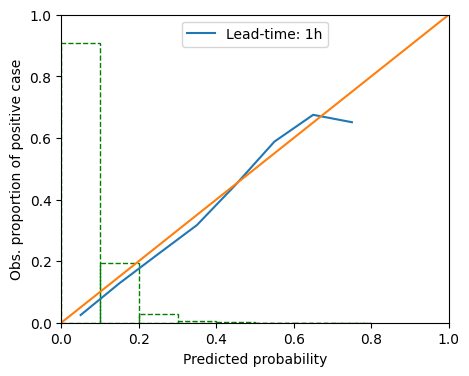

In [ ]:
prob_pred, prob_true, no_pred_per_bin = reliability_curve(y_test.flatten(), pred_y_test.flatten())
plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, label=f"Lead-time: 1h")

plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")

no_pred_per_bin = [i/(1.1*np.max(no_pred_per_bin)) for i in no_pred_per_bin]
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2))
plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")

plt.xlim(0,1)
plt.ylim(0,1)
plt.legend(loc='upper center')
plt.show()

## Plotting

In [ ]:
locations = {
    "Lusaka": [-15.3875, 28.3228],
    "Ndola": [-12.9683, 28.6366],
    "Kasama": [-10.2129, 31.1808],
    "Chinsali": [-10.5500, 32.0667],
    "Kabwe": [-14.4469, 28.4464],
    "Livingstone": [-17.8419, 25.8542],
    "Mongu": [-15.2484, 23.1274],
    "Mansa": [-11.1996, 28.8943],
    "Solwezi": [-12.1722, 26.3981],
    "Chipata": [-13.6339, 32.6508]
}

In [ ]:
lats, lons = zip(*locations.values())

In [ ]:
index_display = 4080

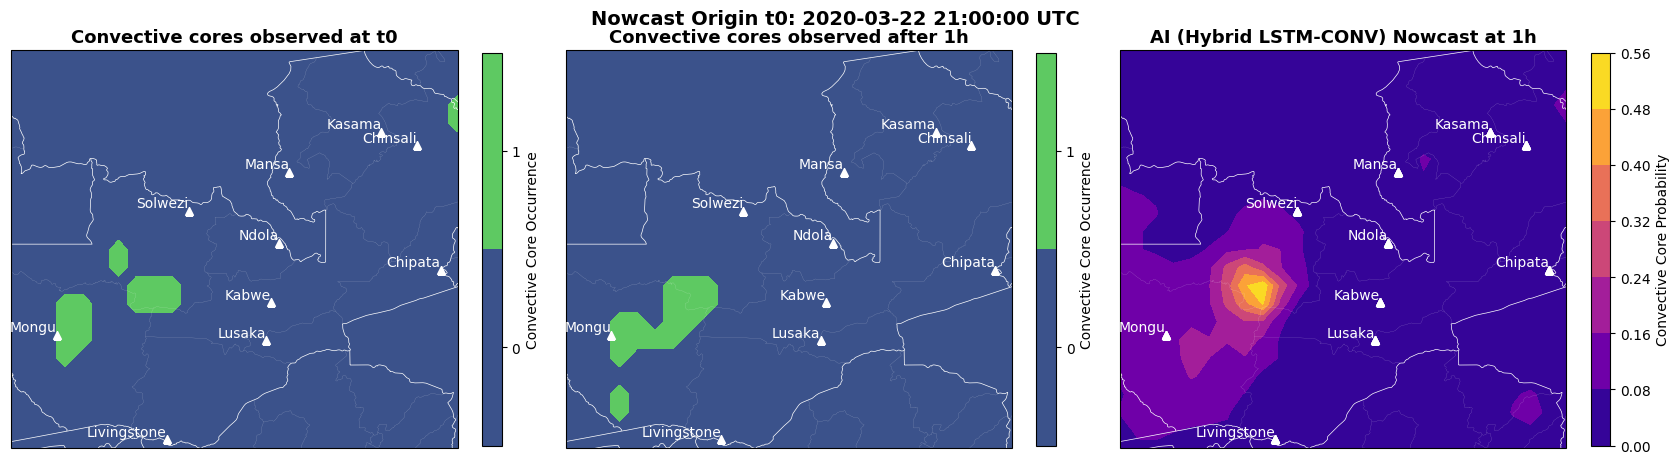

In [ ]:
# Parameters
extent = (22, 33.07, -18.070, -8.194)
lon_min, lon_max, lat_min, lat_max = extent
n_rows, n_cols = 23, 26  # Number of latitude points and longitude points

# Create linearly spaced values for latitudes and longitudes and create meshgrids
latitudes = np.linspace(lat_min, lat_max, n_rows)
longitudes = np.linspace(lon_min, lon_max, n_cols)
lon_grid, lat_grid = np.meshgrid(longitudes, latitudes)

# Index for data to display
to_display = [
    test_data_y_lt0[index_display],  # Add new data here
    y_test[index_display],
    pred_y_test.reshape(len(y_test), n_rows, n_cols)[index_display],
]
titles = ["Convective cores observed at t0", "Convective cores observed after 1h", "AI (Hybrid LSTM-CONV) Nowcast at 1h"]

colormaps = ["viridis", "viridis", "plasma"]  # Add colormap for the new subplot

# Create three subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(17, 5), subplot_kw={'projection': ccrs.PlateCarree()})

# Loop through the axes to plot each subplot
for i, ax in enumerate(axes):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS, edgecolor='white', linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, edgecolor='white')
    ax.add_feature(cfeature.LAND, edgecolor='white')
    ax.tick_params(bottom=True, left=True, top=False, right=False)

    for name, (lat, lon) in locations.items():
      ax.plot(lon, lat, marker="^", color="white")

    admin_1_borders = cfeature.NaturalEarthFeature(
      category='cultural',
      name='admin_1_states_provinces_lines',
      scale='10m',
      facecolor='none')

    ax.add_feature(admin_1_borders, edgecolor='white', linewidth=0.07)

    # Plot data with appropriate colormap
    if i == 0 or i == 1:  # True Binary target
        contour = ax.contourf(
            lon_grid, lat_grid, to_display[i], transform=ccrs.PlateCarree(), cmap=colormaps[i], levels=[-0.5, 0.5, 1.5]
        )
        # Add discrete colorbar
        cbar = fig.colorbar(contour, ax=ax, orientation='vertical', fraction=0.04, pad=0.05, ticks=[0, 1])
        cbar.set_label("Convective Core Occurrence")
        cbar.ax.set_yticklabels(["0", "1"])

    else:  # Continuous or additional data target
        contour = ax.contourf(
            lon_grid, lat_grid, to_display[i], transform=ccrs.PlateCarree(), cmap=colormaps[i]
        )
        # Add continuous colorbar
        cbar = fig.colorbar(contour, ax=ax, orientation='vertical', fraction=0.04, pad=0.05)
        cbar.set_label("Probability" if i == 1 else "Convective Core Probability")

    ax.set_title(titles[i], fontsize=13, fontweight='bold')


    for name, (lat, lon) in locations.items():
        plt.plot(lon, lat, marker="^", color="white")
        ax.text(lon, lat, name, fontsize=10, transform=ccrs.PlateCarree(), ha='right', va='bottom', color='white', zorder=10)


# Adjust layout and display
plt.tight_layout()


data_display = test_data_X.iloc[index_display]
year = int(data_display["year_120"])
month = int(data_display["month_120"])
day = int(data_display["day_120"])
hour = int(data_display["hour_120"])
minute = int(data_display["minute_120"])



# Create a datetime object
nowcast_origin = datetime.datetime(year, month, day, hour, minute)
plt.suptitle(f"Nowcast Origin t0: {nowcast_origin} UTC", fontsize=14, fontweight='bold')
plt.show()

### Fraction Skill Score

In [ ]:
from scipy.ndimage import uniform_filter

def compute_fss(observation, prediction, threshold=0.15, neighborhood_size=3):
    """
    Compute the Fraction Skill Score (FSS) for an observation and prediction.

    Parameters:
        observation (np.ndarray): Ground truth binary field (2D array).
        prediction (np.ndarray): Predicted binary field (2D array).
        threshold (float): Threshold to binarize the observation and prediction.
        neighborhood_size (int): Size of the moving window for fraction computation.

    Returns:
        float: Fraction Skill Score (FSS).
    """
    # Binarize observation and prediction
    obs_binary = (observation >= threshold).astype(float)
    pred_binary = (prediction >= threshold).astype(float)

    # Compute fractions using a uniform filter for the neighborhood
    obs_fraction = uniform_filter(obs_binary, size=neighborhood_size, mode='constant')
    pred_fraction = uniform_filter(pred_binary, size=neighborhood_size, mode='constant')

    # Compute the Mean Squared Error (MSE)
    mse = np.mean((obs_fraction - pred_fraction) ** 2)

    # Compute the reference MSE (MSE_ref)
    mse_ref = np.mean(obs_fraction ** 2 + pred_fraction ** 2)

    # Compute the Fraction Skill Score (FSS)
    fss = 1 - mse / mse_ref

    return fss

In [ ]:
compute_fss(y_test[index_display], pred_y_test.reshape(len(y_test), n_rows, n_cols)[index_display])

0.7236363636363636

In [ ]:
#model.save("/content/drive/MyDrive/Zambia/Zambia-lt1-v1-0.15.keras")